# CREDIT CARD FRAUD DETECTION

# Import Libraries

In [29]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

# Imbalance Handling
from imblearn.over_sampling import SMOTE

# Save model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [30]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [31]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Exploratory Data Analysis

# Class Distribution

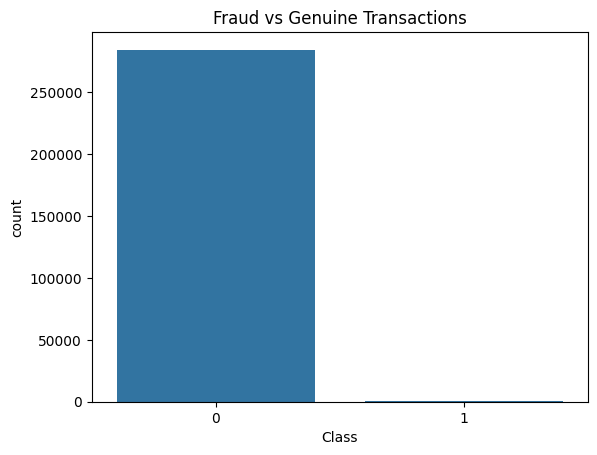

Class
0    284315
1       492
Name: count, dtype: int64


In [32]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

print(df['Class'].value_counts())


# 
Percentage of Fraud

In [33]:
fraud_percent = (df['Class'].value_counts()[1] / len(df)) * 100
print("Fraud Percentage:", fraud_percent)


Fraud Percentage: 0.1727485630620034


# Correlation Heatmap

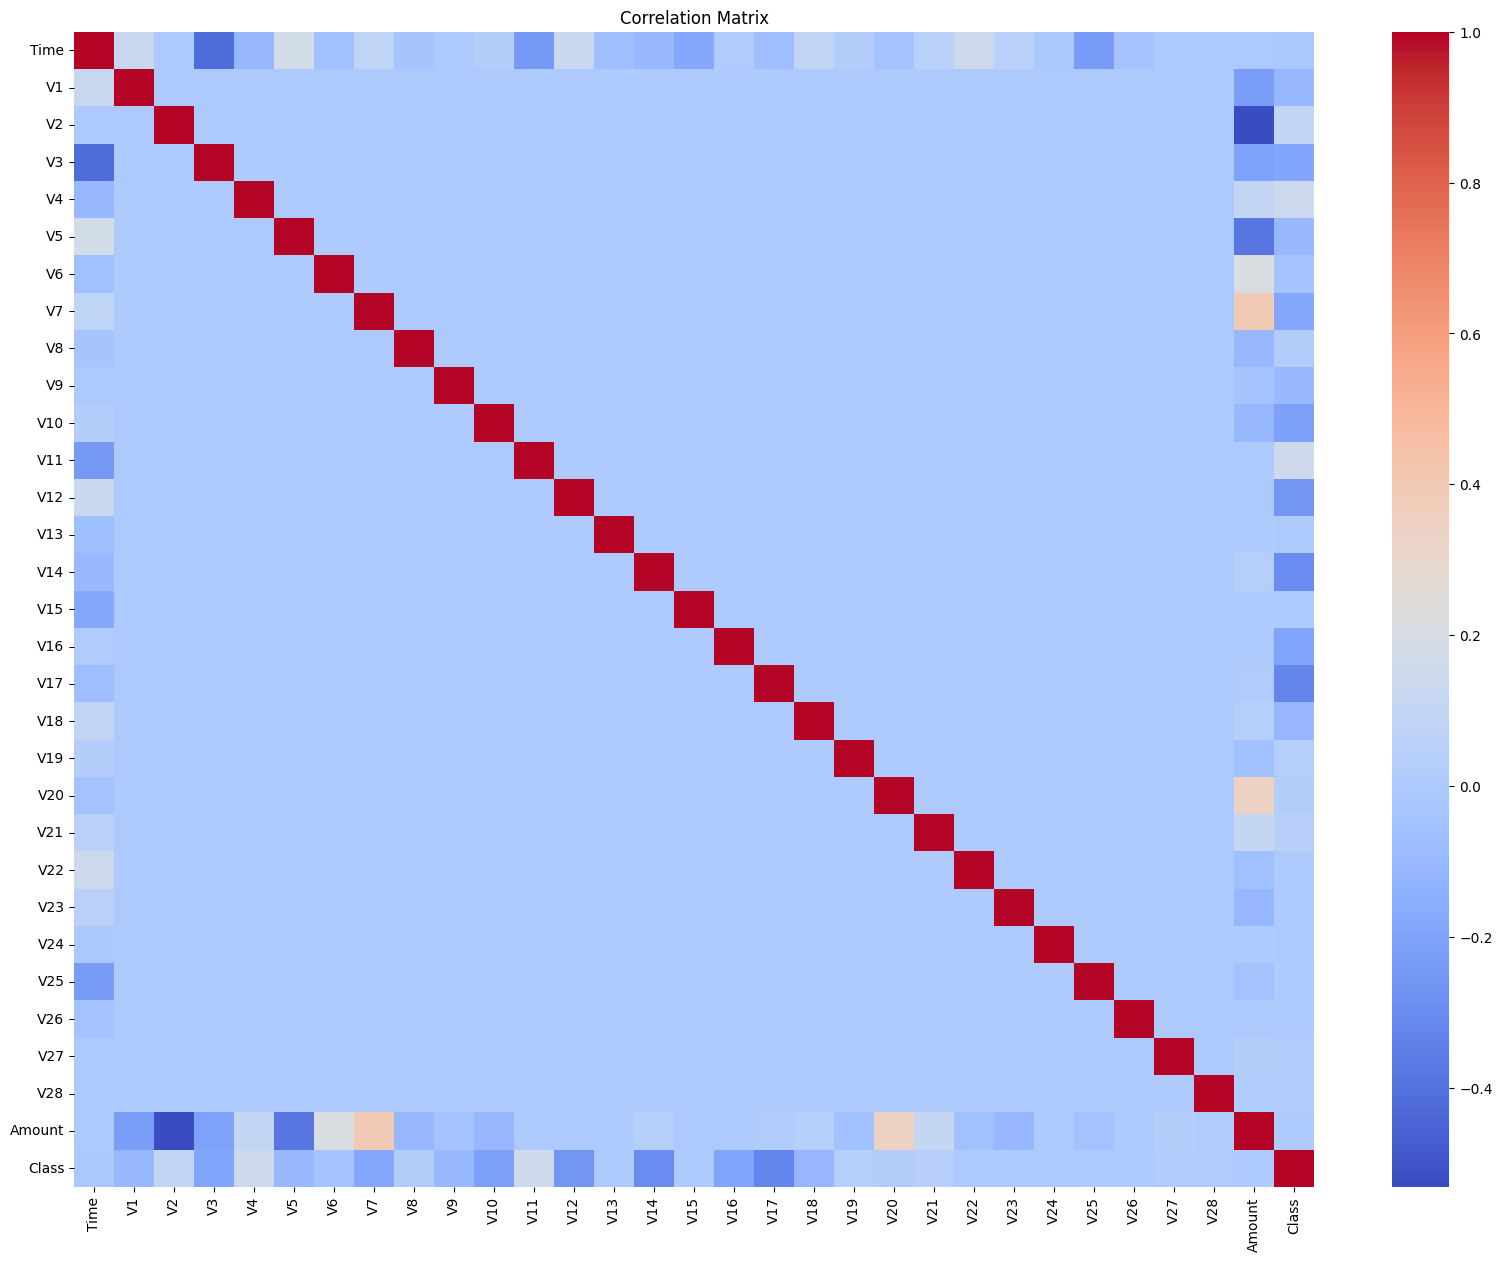

In [34]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()



# Data Preprocessing

# Normalize Time and Amount

In [35]:
scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

df.drop(['Time','Amount'], axis=1, inplace=True)


# Split Data

In [36]:

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Handle Class Imbalance

In [37]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())


Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


# Model 1 – Logistic Regression

In [38]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Results
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



# Model 2 – Random Forest

In [39]:

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,              # Use all CPU cores
    class_weight='balanced' # Handle imbalance automatically
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))


Random Forest Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



# Model 3 – XGBoost

In [40]:
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1)
xgb.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results")
print(classification_report(y_test, y_pred_xgb))


XGBoost Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.88      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



# Model Evaluation Comparison

In [41]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print("Model:", name)
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_pred))
    print("-"*50)



Model: Logistic Regression
Precision: 0.05813953488372093
Recall: 0.9183673469387755
F1 Score: 0.10935601458080195
ROC AUC: 0.9463636115673055
--------------------------------------------------
Model: Random Forest
Precision: 0.961038961038961
Recall: 0.7551020408163265
F1 Score: 0.8457142857142858
ROC AUC: 0.8775246416799696
--------------------------------------------------
Model: XGBoost
Precision: 0.7226890756302521
Recall: 0.8775510204081632
F1 Score: 0.7926267281105991
ROC AUC: 0.9384853441939521
--------------------------------------------------


# Hyperparameter Tuning

In [42]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

grid = GridSearchCV(
    rf,
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,   # Parallel processing
    verbose=2
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time= 1.7min
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time= 3.3min
[CV] END .max_depth=5, min_samples_split=5, n_estimators=200; total time= 3.3min
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time= 2.6min
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time= 2.5min
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time= 2.6min
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


# Save Best Model



In [48]:


best_model = grid.best_estimator_


In [49]:
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [50]:
import os
import joblib

# Create models directory
base_path = os.getcwd()
model_dir = os.path.join(base_path, "models")
os.makedirs(model_dir, exist_ok=True)

# Save model
model_path = os.path.join(model_dir, "best_model.pkl")
joblib.dump(best_model, model_path)

print("Model saved at:", model_path)


Model saved at: /kaggle/working/models/best_model.pkl


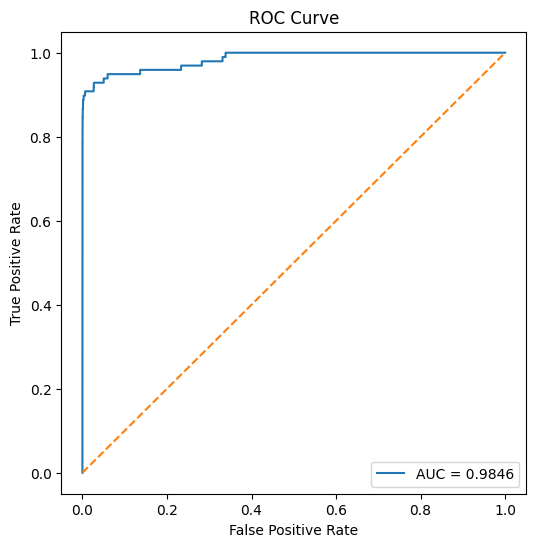

ROC-AUC Score: 0.9846181508619205
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time= 1.7min
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time= 1.7min
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time= 1.7min
[CV] END .max_depth=5, min_samples_split=5, n_estimators=200; total time= 3.4min
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time= 5.2min
[CV] END max_depth=10, min_samples_split=5, n_estimators=200; total time= 4.3min


In [51]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", auc_score)


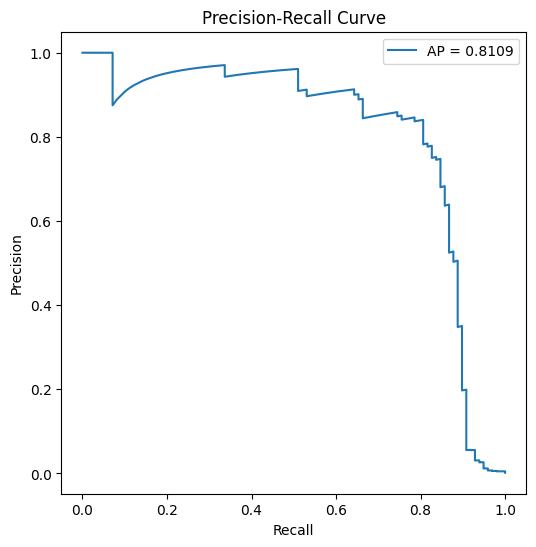

Average Precision Score: 0.8109468456856154


In [52]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print("Average Precision Score:", ap_score)


In [54]:
# Prediction Function (Production Ready)
def predict_transaction(input_data):
    model = joblib.load("models/best_model.pkl")
    prediction = model.predict([input_data])
    return "Fraud" if prediction[0] == 1 else "Genuine"

In [56]:
def predict_transaction(input_data, threshold=0.5):
    """
    Predict if a transaction is Fraud or Genuine
    
    Parameters:
    input_data : list or array (single transaction features)
    threshold : decision threshold (default=0.5)
    
    Returns:
    dict with prediction and probability
    """
    
    # Convert to numpy array
    input_array = np.array(input_data).reshape(1, -1)
    
    # Get probability
    prob = model.predict_proba(input_array)[0][1]
    
    # Apply custom threshold
    prediction = 1 if prob >= threshold else 0
    
    return {
        "Fraud Probability": round(float(prob), 4),
        "Prediction": "Fraud" if prediction == 1 else "Genuine"
    }


In [57]:
sample_transaction = X_test.iloc[0].values

result = predict_transaction(sample_transaction, threshold=0.3)

print(result)


{'Fraud Probability': 0.0, 'Prediction': 'Genuine'}
